# 🎙️ IntelliMin : Voice-to-Text Meeting Minutes Automator
### Beginner-Friendly NLP Project Notebook (Dataset: archive (1).zip)
---
## 📐 Simple Project Flow
```text
Meeting Text (archive (1).zip / meeting_dataset.csv)
     │
     ▼
Preprocessing (clean_text)
     │
     ▼
TF-IDF (TfidfVectorizer)
     │
     ▼
Naïve Bayes (MultinomialNB)
     │
     ▼
Decision / Action Item / Discussion
     │
     ▼
Action Item Extraction
     │
     ▼
Word Cloud + Category Graph
```

### 1. Import libraries

In [33]:
# Imports pandas data processing library
import pandas as pd
# Imports regular expression string module
import re
# Imports matplotlib graph plotting library
import matplotlib.pyplot as plt

# Imports Scikit-Learn TFIDF and Naive Bayes
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
# Imports WordCloud visual generator module
from wordcloud import WordCloud

# Confirms module import success
print("✅ All NLP libraries imported successfully!")

✅ All NLP libraries imported successfully!


### 2. Create simple meeting dataset from archive (1).zip

In [34]:
# Loads dataset extracted from archive (1).zip
df = pd.read_csv("meeting_dataset.csv")

# Displays first few rows of dataset
print(df.head(10))
print("\nDataset Category Counts:")
print(df["Category"].value_counts())

                                                Text    Category
0  Thank you so much for this introduction and I'...  Discussion
1  So first of all, I'd like to thank most of the...  Discussion
2  Sunburg to come if you are from anywhere in th...  Discussion
3               Place which is growing pretty nicely  Discussion
4  Zoom out, you see where I was born, which is t...  Discussion
5  Zooming back where we are in Luxembourg at the...  Discussion
6  Their research efforts, so if you compare Luxe...  Discussion
7      This is just a little olm that we didn't mean  Discussion
8  That's yesterday night, so I needed a little s...    Decision
9  Really coming back and thanks to this Castle n...  Discussion

Dataset Category Counts:
Discussion     50
Decision       50
Action Item    50
Name: Category, dtype: int64


### 3. Preprocess the meeting text

In [35]:
# Cleans text string for processing
def clean_text(text):
    # Converts text to lower case
    text = str(text).lower()
    # Removes non-alphabetical punctuation symbols
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text

# Applies clean_text to dataset column
df["Clean_Text"] = df["Text"].apply(clean_text)
# Displays original and cleaned text
print(df[["Text", "Clean_Text"]].head())

                                                Text  \
0  Thank you so much for this introduction and I'...   
1  So first of all, I'd like to thank most of the...   
2  Sunburg to come if you are from anywhere in th...   
3               Place which is growing pretty nicely   
4  Zoom out, you see where I was born, which is t...   

                                          Clean_Text  
0  thank you so much for this introduction and im...  
1  so first of all id like to thank most of the c...  
2  sunburg to come if you are from anywhere in th...  
3               place which is growing pretty nicely  
4  zoom out you see where i was born which is the...  


### 4. Convert text into TF-IDF

In [36]:
# Initializes TfidfVectorizer feature extractor
vectorizer = TfidfVectorizer()

# Transforms cleaned text into vector
X = vectorizer.fit_transform(df["Clean_Text"])
# Defines target label category output
y = df["Category"]

# Prints feature matrix dimensions
print("TF-IDF Matrix Shape:", X.shape)

TF-IDF Matrix Shape: (150, 1003)


### 5. Train the model

In [37]:
# Initializes Multinomial Naive Bayes classifier
model = MultinomialNB()

# Trains classifier model on vectors
model.fit(X, y)
# Prints successful model training message
print("✅ Model trained successfully on dataset!")

✅ Model trained successfully on dataset!


### 6. Classify a new meeting sentence

In [38]:
# Defines new test meeting sentence
new_text = [
    "Rahul will complete the project report tomorrow."
]

# Preprocesses new input test sentence
new_text = [clean_text(text) for text in new_text]

# Transforms test text to TF-IDF
new_vector = vectorizer.transform(new_text)

# Predicts category using trained model
prediction = model.predict(new_vector)
# Displays predicted category label result
print("Category:", prediction[0])

Category: Action Item


### 7. Find action items

In [39]:
# Defines list of action keywords
action_words = [
    "will",
    "should",
    "must",
    "complete",
    "prepare",
    "submit"
]

print("Action Items:")
# Iterates sentences to find keywords
for text in df["Text"]:
    if any(word in str(text).lower() for word in action_words):
        print("-", text)

Action Items:
- And you will see later why I'm boring you with this
- And if you look at data, you see what, let's say, 1300 commercial jet aircraft will losts in about let's say 50 years 1959 to 2000
- As you can imagine that over the A380, which is about 80 meter in weeks wingspan, you have quite a few of these bolted joints and that if you need indeed 2 billion elements for each of them because they are all coupled together, then you should wake up earlier in the morning to start your calculations because it's going to take quite some time
- Part that I will talk about
- So once we figured out where the pools where we decided OK, now we will initiate a crack
- Propagation, and this is what you can typically see, so you will see that the crack will propagate
- So this is what led us to this, because we thought that we had the tools necessary to tackle the problems, but little did we know and you will see now why
- Is quite important because the challenge is really that everything hap

### 8. Word Cloud

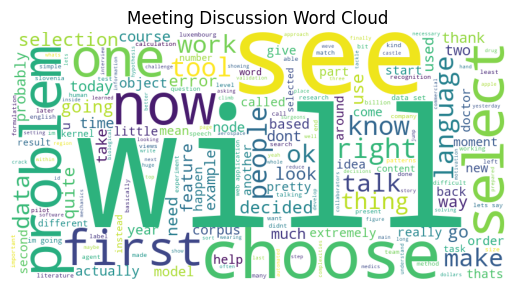

In [40]:
# Combines all clean sentences together
all_text = " ".join(df["Clean_Text"])

# Generates WordCloud visualization image object
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(all_text)

# Renders wordcloud image plot view
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Meeting Discussion Word Cloud")
plt.show()

### 9. Category graph

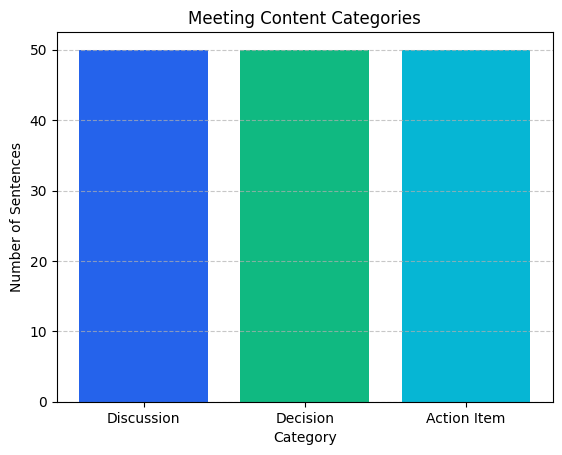

In [41]:
# Plots category frequency bar graph
category_count = df["Category"].value_counts()
plt.bar(category_count.index, category_count.values, color=['#2563EB', '#10B981', '#06B6D4'])
plt.title("Meeting Content Categories")
plt.xlabel("Category")
plt.ylabel("Number of Sentences")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
